In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/traffic_events.csv
/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/road_network_international.csv
/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/sensor_locations.json
/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/traffic_sensor_data.csv
/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/traffic_prediction_config.json
/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/weather_conditions.csv
/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/road_network.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rauffauzanrambe/smart-city-traffic-flow-prediction-dataset/road_network.csv')
df.head()

,road_id,road_name,road_type,length_km,lanes,speed_limit_kmh,capacity_vehicles_per_hour,has_bus_lane,has_bike_lane,surface_condition,last_maintenance_date,latitude_start,longitude_start,latitude_end,longitude_end,district,toll_rate_rp,avg_daily_traffic
0,RD-0001,Jl. Segment 1,Jalan Kolektor,4.3,4,60,5384,0,0,Cukup,2022-12-21,-6.173938,106.920654,-6.187271,106.937674,PIK,0,10833
1,RD-0002,Jl. Segment 2,Jalan Arteri,4.3,4,80,6132,0,0,Baik,2022-11-17,-6.248396,106.768647,-6.246220,106.771962,Depok,0,6921
2,RD-0003,Jl. Segment 3,Jalan Lokal,1.8,2,40,978,0,0,Cukup,2023-04-15,-6.267631,106.814963,-6.264098,106.831007,Tangerang,0,1085
3,RD-0004,Jl. Segment 4,Jalan Kolektor,1.8,4,60,4160,0,1,Rusak Berat,2022-05-17,-6.112216,106.954036,-6.122268,106.958261,Mangga Dua,0,6145
4,RD-0005,Jl. Segment 5,Jalan Tol,22.7,4,80,6600,1,0,Baik,2024-02-16,-6.349760,106.861835,-6.341074,106.856648,Sudirman,7000,8023


**drop_columns**

In [3]:
drop_columns = [
    "road_id",
    "road_name",
    "last_maintenance_date"
]

df = df.drop(columns=drop_columns)

**Encoding**

In [4]:
categorical_columns = [
    "road_type",
    "district"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    dtype=int
)

****

**Ordinal Encoding**

In [5]:
surface_mapping = {
    "Rusak Berat": 0,    # 嚴重損壞
    "Rusak Ringan": 1,   # 輕微損壞
    "Cukup": 2,          # 普通／尚可
    "Baik": 3            # 良好
}

df["surface_condition"] = df["surface_condition"].map(surface_mapping)

In [6]:
df.isnull().sum()

length_km                     0
lanes                         0
speed_limit_kmh               0
capacity_vehicles_per_hour    0
has_bus_lane                  0
has_bike_lane                 0
surface_condition             0
latitude_start                0
longitude_start               0
latitude_end                  0
longitude_end                 0
toll_rate_rp                  0
avg_daily_traffic             0
road_type_Jalan Arteri        0
road_type_Jalan Kolektor      0
road_type_Jalan Lingkungan    0
road_type_Jalan Lokal         0
road_type_Jalan Tol           0
district_Bekasi               0
district_Blok M               0
district_Cakung               0
district_Cawang               0
district_Cibubur              0
district_Depok                0
district_Grogol               0
district_Kelapa Gading        0
district_Kemang               0
district_Kuningan             0
district_Mangga Dua           0
district_Menteng              0
district_PIK                  0
district

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   length_km                   200 non-null    float64
 1   lanes                       200 non-null    int64  
 2   speed_limit_kmh             200 non-null    int64  
 3   capacity_vehicles_per_hour  200 non-null    int64  
 4   has_bus_lane                200 non-null    int64  
 5   has_bike_lane               200 non-null    int64  
 6   surface_condition           200 non-null    int64  
 7   latitude_start              200 non-null    float64
 8   longitude_start             200 non-null    float64
 9   latitude_end                200 non-null    float64
 10  longitude_end               200 non-null    float64
 11  toll_rate_rp                200 non-null    int64  
 12  avg_daily_traffic           200 non-null    int64  
 13  road_type_Jalan Arteri      200 non

In [8]:
df["avg_daily_traffic"].describe()

count      200.000000
mean      5497.510000
std       5264.646678
min        353.000000
25%       1167.750000
50%       3675.000000
75%       8847.250000
max      28394.000000
Name: avg_daily_traffic, dtype: float64

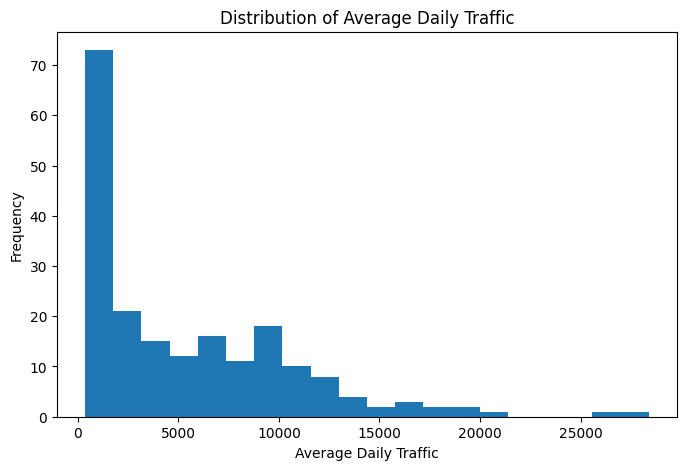

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["avg_daily_traffic"], bins=20)

plt.title("Distribution of Average Daily Traffic")
plt.xlabel("Average Daily Traffic")
plt.ylabel("Frequency")

plt.show()

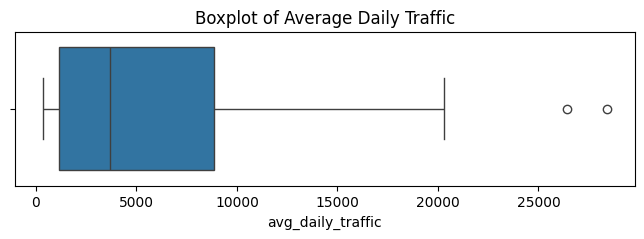

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,2))

sns.boxplot(x=df["avg_daily_traffic"])

plt.title("Boxplot of Average Daily Traffic")

plt.show()

**Neural Network Standardization**

In [11]:
X = df.drop(columns=["avg_daily_traffic"])
y = df["avg_daily_traffic"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 使用訓練集計算平均值與標準差
X_train = scaler.fit_transform(X_train)

# 使用相同的平均值與標準差轉換測試集
X_test = scaler.transform(X_test)

**Neural Network**

In [14]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42)

In [15]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 7641.64223806  3096.93272686  4609.51170535  4886.27787658
 22225.93448527  4645.65800467  5243.26584796   897.5382852
  7615.21068315  2961.8774465 ]


**Model Evaluation**

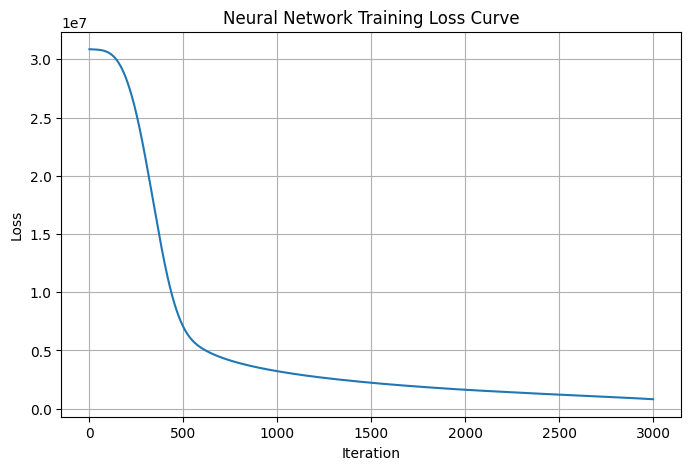

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(model.loss_curve_)

plt.title("Neural Network Training Loss Curve")

plt.xlabel("Iteration")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

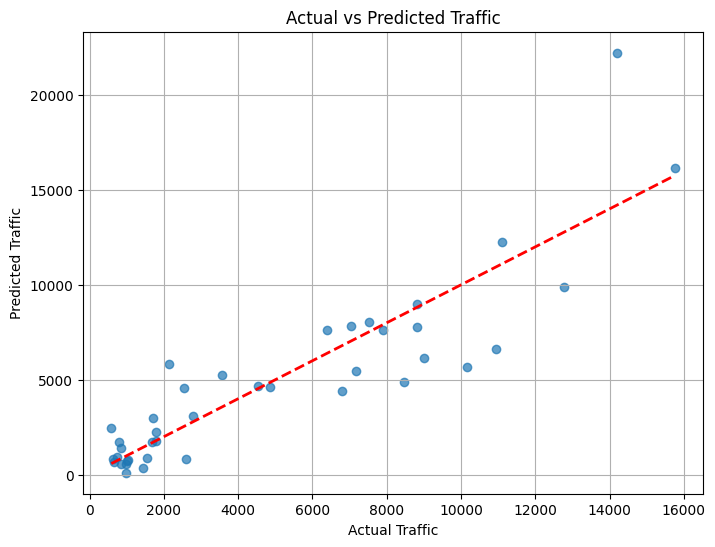

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# 理想預測線 (y=x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Actual vs Predicted Traffic")

plt.grid(True)

plt.show()

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1377.42
MSE  : 4491756.59
RMSE : 2119.38
R²   : 0.7543


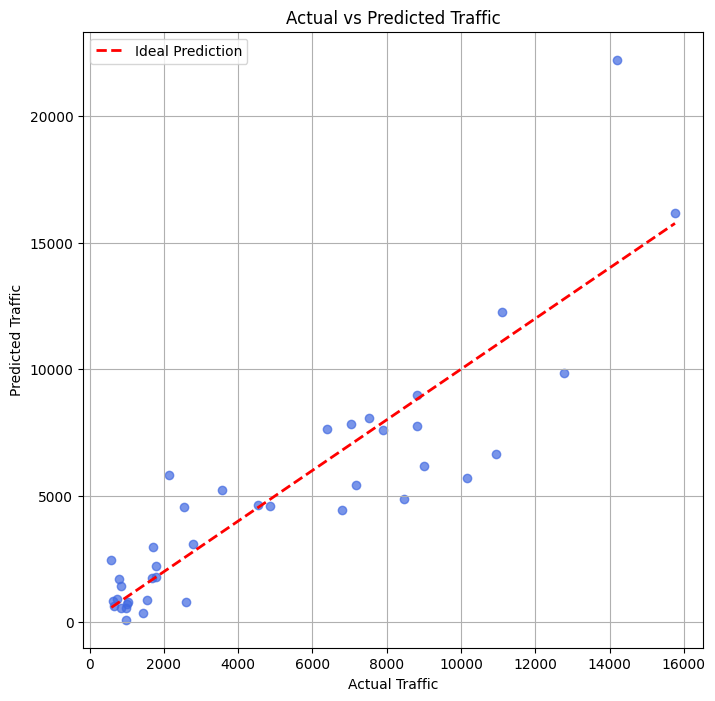

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# 繪製散佈圖
plt.scatter(y_test, y_pred,
            color='royalblue',
            alpha=0.7)

# 繪製理想預測線 (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Ideal Prediction'
)

plt.title("Actual vs Predicted Traffic")
plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")

plt.legend()
plt.grid(True)

plt.show()

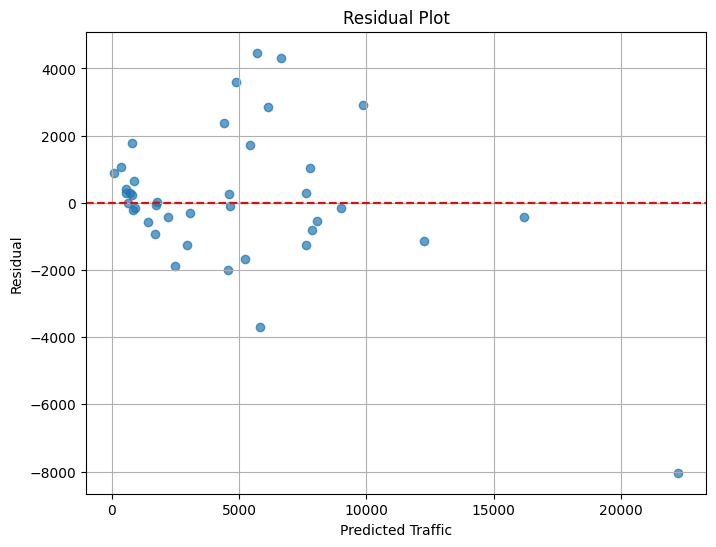

In [20]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residual, alpha=0.7)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Traffic")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

| 排名    | 指標                  | 為什麼        |
| ----- | ------------------- | ---------- |
| ⭐⭐⭐⭐⭐ | RMSE                | 最能反映實際預測誤差 |
| ⭐⭐⭐⭐⭐ | R²                  | 最容易比較模型好壞  |
| ⭐⭐⭐⭐⭐ | Actual vs Predicted | 一眼看出模型是否準確 |
| ⭐⭐⭐⭐  | Loss Curve          | 看神經網路是否收斂  |
| ⭐⭐⭐⭐  | MAE                 | 平均誤差，容易解釋  |
| ⭐⭐⭐   | Residual Plot       | 檢查模型是否有偏差  |
